In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [74]:
datos1=pd.read_csv('bobina.csv')
datos2=pd.read_csv('hall.csv')

In [75]:
V=datos1['V']
I=datos1['I']
B=[]
II=[]
BB=[]
for i in range(0,len(V)):
    b=datos1['B1'][i]+datos1['B2'][i]+datos1['B3'][i]+datos1['B4'][i]+datos1['B5'][i]
    B.append(b/5)
    if I[i]>0:
      II.append(I[i])
      BB.append(B[i])
regI=linregress(II,BB)
regV=linregress(V,B)

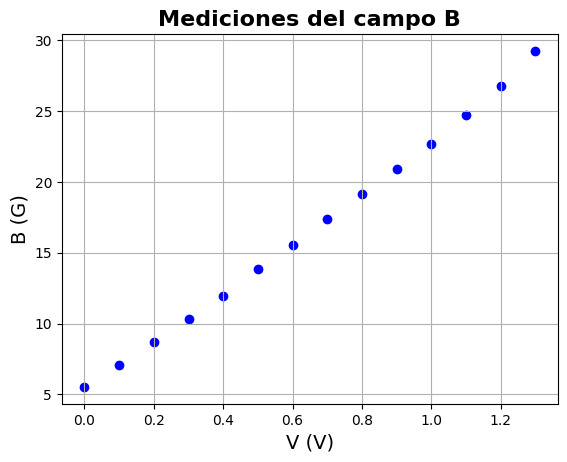

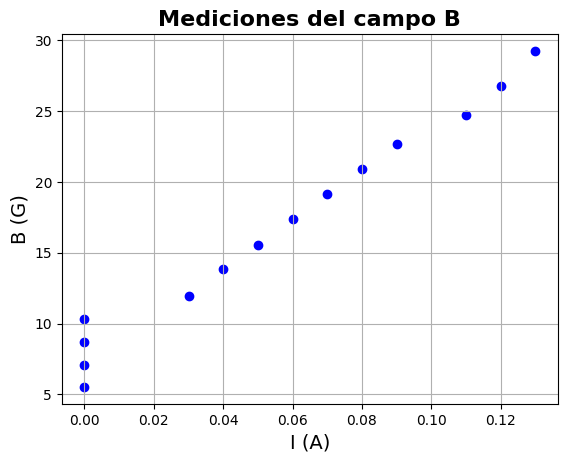

In [76]:
plt.scatter(V,B,color='blue')
plt.title("Mediciones del campo B",fontsize=16,fontweight='bold')
plt.ylabel("B (G)", fontsize=14)
plt.xlabel("V (V)", fontsize=14)
plt.grid()
plt.show()
plt.scatter(I,B,color='blue')
plt.title("Mediciones del campo B",fontsize=16,fontweight='bold')
plt.ylabel("B (G)", fontsize=14)
plt.xlabel("I (A)", fontsize=14)
plt.grid()
plt.show()

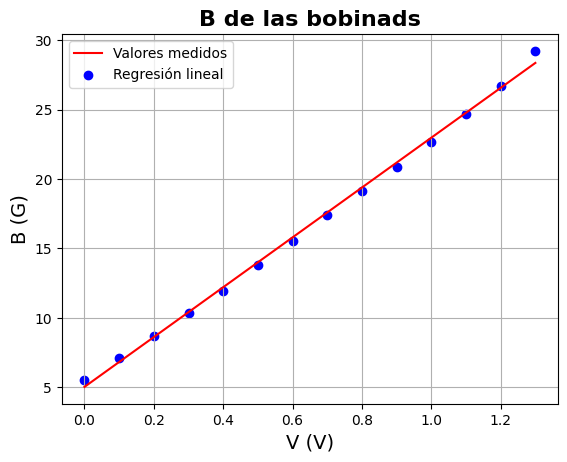

m=  17.963780219780222
c=  5.018399999999996
err=  0.24100257658219604


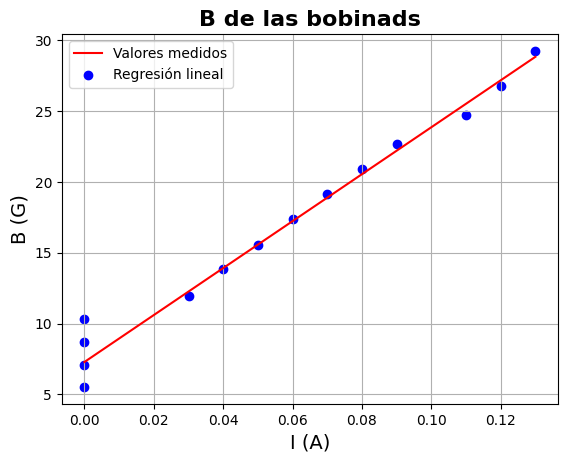

m=  165.58409090909097
c=  7.291840909090904
err=  4.349043302026879


In [77]:
v=np.linspace(V[0],V[len(V)-1])
i=np.linspace(I[0],I[len(I)-1])
plt.plot(v,regV.slope*v+regV.intercept,color='red')
plt.scatter(V,B,color='blue')
plt.title("B de las bobinads",fontsize=16,fontweight='bold')
plt.ylabel("B (G)", fontsize=14)
plt.xlabel("V (V)", fontsize=14)
plt.legend(['Valores medidos','Regresión lineal'])
plt.grid()
plt.show()
print('m= ',regV.slope)
print('c= ',regV.intercept)
print('err= ',regV.stderr)
plt.plot(i,regI.slope*i+regI.intercept,color='red')
plt.scatter(I,B,color='blue')
plt.title("B de las bobinads",fontsize=16,fontweight='bold')
plt.ylabel("B (G)", fontsize=14)
plt.xlabel("I (A)", fontsize=14)
plt.legend(['Valores medidos','Regresión lineal'])
plt.grid()
plt.show()
print('m= ',regI.slope)
print('c= ',regI.intercept)
print('err= ',regI.stderr)

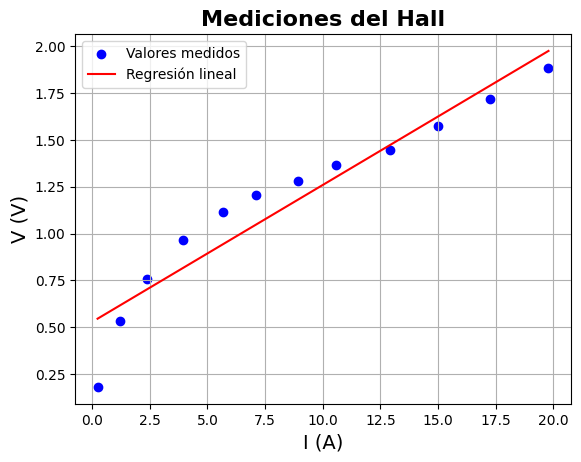

m=  0.07316111259663213
c=  0.5280158777419366
err=  0.007390366055562483


In [95]:
ih=[]
ihsigma=[]
vh=[]
vhsigma=[]
for i in range(0,12):
  tem1=[datos2['I1'][i],datos2['I2'][i],datos2['I3'][i],datos2['I4'][i],datos2['I5'][i]]
  tem2=[datos2['V1'][i],datos2['V2'][i],datos2['V3'][i],datos2['V4'][i],datos2['V5'][i]]
  ih.append(np.mean(tem1))
  vh.append(np.mean(tem2))
  vhsigma.append(np.std(tem2))
  ihsigma.append(np.std(tem1))
d=300*10**(-4)
ih=np.array(ih)
ih=np.abs(ih)
Bh=regV.slope * 1 +regV.intercept
bherr=regV.stderr
re=linregress(ih,vh)
plt.scatter(ih,vh,color='blue')
plt.plot(ih,re.slope*ih+re.intercept,color='red')
plt.title("Mediciones del Hall",fontsize=16,fontweight='bold')
plt.ylabel("V (V)", fontsize=14)
plt.xlabel("I (A)", fontsize=14)
plt.legend(['Valores medidos','Regresión lineal'])
plt.grid()
plt.show()
print('m= ',re.slope)
print('c= ',re.intercept)
print('err= ',re.stderr)

12 12 12


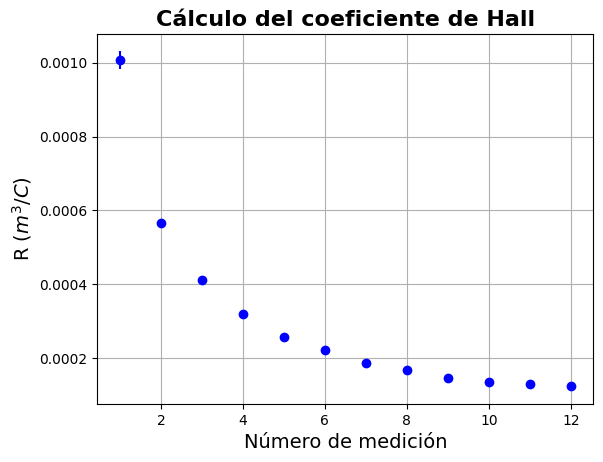

In [97]:
R=d*np.array(vh)/(Bh*np.array(ih))
Rsig=np.abs(R)*np.sqrt((np.array(ihsigma)/np.array(ih))**2+(np.array(vhsigma)/np.array(vh))**2+(np.array(bherr)/Bh)**2)
n=list(range(1,13))
print(len(n),len(R),len(Rsig))
plt.errorbar(n,R,yerr=Rsig,fmt='o',color='blue')
plt.title("Cálculo del coeficiente de Hall",fontsize=16,fontweight='bold')
plt.ylabel(r'R $(m^3/C)$', fontsize=14)
plt.xlabel("Número de medición", fontsize=14)
plt.grid()
plt.show()

In [99]:
Rprom=np.mean(R)
Rsigprom=np.std(R)/np.sqrt(len(R))
print('R= ',Rprom,' +/- ',Rsigprom)

R=  0.00030628659257689973  +/-  7.125985205740992e-05
